In [1]:
#imports
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt


In [2]:
#Loding Dataset
df = pd.read_csv('/content/customer_support_tickets.csv')

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [3]:
print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [4]:
df = df[['Ticket Description', 'Ticket Type']]

df.head()

,Ticket Description,Ticket Type
0,I'm having an issue with the {product_purchase...,Technical issue
1,I'm having an issue with the {product_purchase...,Technical issue
2,I'm facing a problem with my {product_purchase...,Technical issue
3,I'm having an issue with the {product_purchase...,Billing inquiry
4,I'm having an issue with the {product_purchase...,Billing inquiry


In [5]:
#handling missing values
df.dropna(inplace=True)

print(df.isnull().sum())

Ticket Description    0
Ticket Type           0
dtype: int64


In [7]:
X = df['Ticket Description']

y = df['Ticket Type']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
vectorizer = TfidfVectorizer()

X_train_vectorized = vectorizer.fit_transform(X_train)

X_test_vectorized = vectorizer.transform(X_test)

In [11]:
model = MultinomialNB()

model.fit(X_train_vectorized, y_train)

print("Model trained successfully!")

Model trained successfully!


In [12]:
y_pred = model.predict(X_test_vectorized)

print(y_pred[:10])

['Refund request' 'Product inquiry' 'Refund request'
 'Cancellation request' 'Technical issue' 'Refund request'
 'Refund request' 'Technical issue' 'Technical issue' 'Product inquiry']


In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.19834710743801653


In [14]:
print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.14      0.04      0.06       357
Cancellation request       0.18      0.15      0.17       327
     Product inquiry       0.17      0.12      0.14       316
      Refund request       0.21      0.34      0.26       345
     Technical issue       0.22      0.34      0.27       349

            accuracy                           0.20      1694
           macro avg       0.18      0.20      0.18      1694
        weighted avg       0.18      0.20      0.18      1694



In [15]:
sample_ticket = ["Payment failed during checkout"]

sample_vector = vectorizer.transform(sample_ticket)

prediction = model.predict(sample_vector)

print("Predicted Category:", prediction[0])

Predicted Category: Technical issue


In [16]:
high_priority_keywords = ['failed', 'error', 'urgent', 'not working']

ticket = sample_ticket[0].lower()

priority = "Low"

for word in high_priority_keywords:
    if word in ticket:
        priority = "High"

print("Priority:", priority)

Priority: High


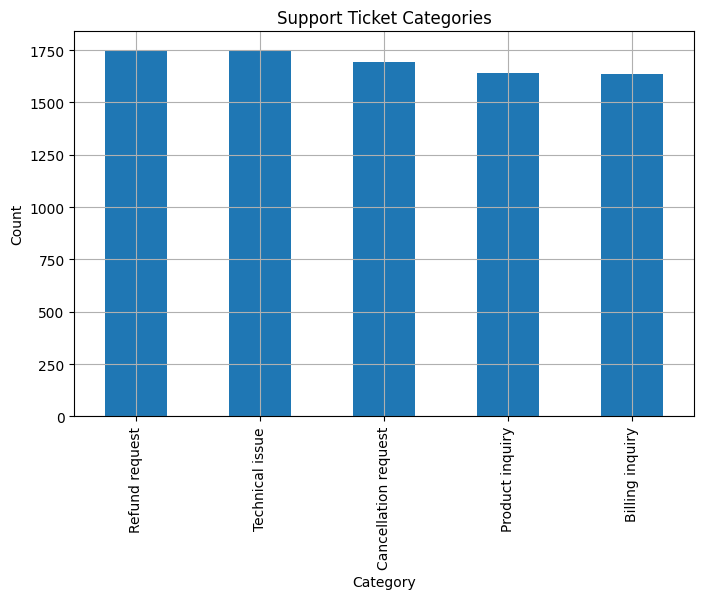

In [18]:
category_counts = df['Ticket Type'].value_counts()

plt.figure(figsize=(8,5))

category_counts.plot(kind='bar')

plt.title('Support Ticket Categories')

plt.xlabel('Category')

plt.ylabel('Count')

plt.grid(True)

plt.show()

In [21]:
full_df = pd.read_csv('/content/customer_support_tickets.csv')

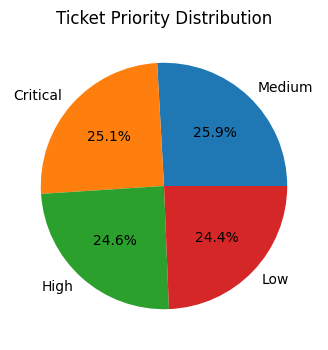

In [22]:
#Ticket Priority Distribution
priority_counts = full_df['Ticket Priority'].value_counts()

plt.figure(figsize=(6,4))

priority_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title('Ticket Priority Distribution')

plt.ylabel('')

plt.show()

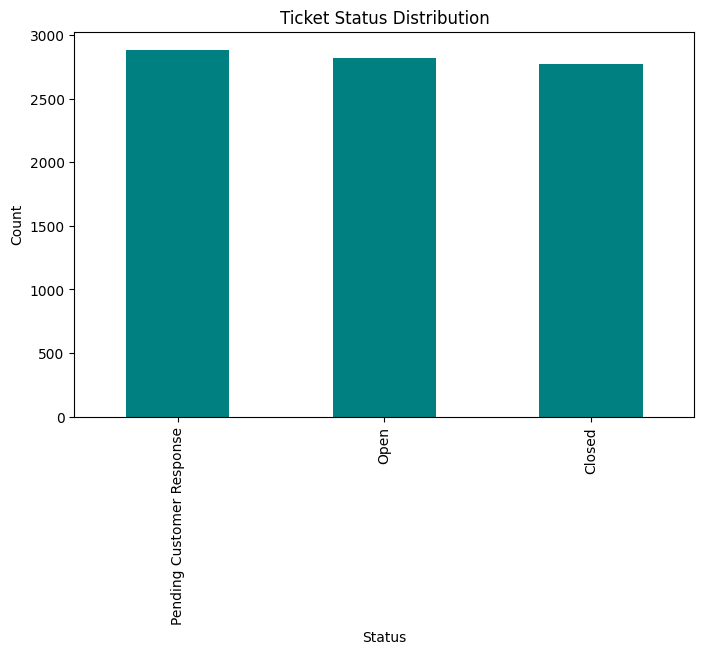

In [26]:
#Ticket Status Distribution
status_counts = full_df['Ticket Status'].value_counts()

plt.figure(figsize=(8,5))

status_counts.plot(
    kind='bar',
    color='teal'
)

plt.title('Ticket Status Distribution')

plt.xlabel('Status')

plt.ylabel('Count')

plt.show()

Business Insights

1. Machine Learning can automatically classify customer support tickets into different categories.
2. NLP-based automation helps reduce manual workload for support teams.
3. Priority detection enables faster handling of urgent customer issues.
4. Ticket analytics provide better understanding of customer problems and service performance.
5. Automated support systems improve customer satisfaction and operational efficiency.